In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

100%|██████████| 2.29G/2.29G [03:24<00:00, 12.1MB/s]

Extracting files...


Path to dataset files: /home/charis/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2


In [1]:
from PIL import Image
img = Image.open("chest_xray/chest_xray/train/NORMAL/IM-0115-0001.jpeg")
img.show()  

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
import os
import numpy as np

Total number of normal images in train set: 1342
Total number of pneumonia images in train set: 3876
Total number of normal images in test set: 234
Total number of pneumonia images in test set: 390
Total number of normal images in validation set: 9
Total number of pneumonia images in validation set: 9


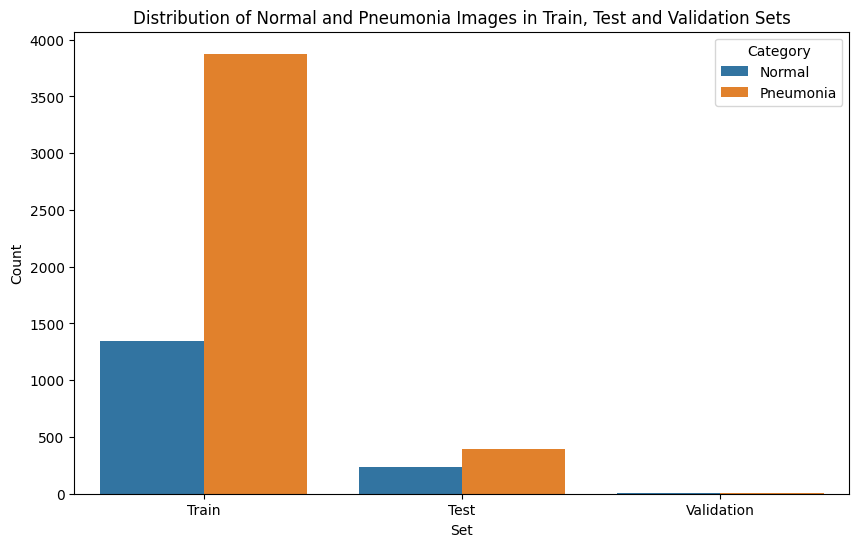

In [16]:
# Check the total number on train, test and validation sets
train_normal = os.listdir("chest_xray/chest_xray/train/NORMAL")
train_pneumonia = os.listdir("chest_xray/chest_xray/train/PNEUMONIA")
test_normal = os.listdir("chest_xray/chest_xray/test/NORMAL")
test_pneumonia = os.listdir("chest_xray/chest_xray/test/PNEUMONIA")
val_normal = os.listdir("chest_xray/chest_xray/val/NORMAL")
val_pneumonia = os.listdir("chest_xray/chest_xray/val/PNEUMONIA")   

print("Total number of normal images in train set:", len(train_normal))
print("Total number of pneumonia images in train set:", len(train_pneumonia))
print("Total number of normal images in test set:", len(test_normal))
print("Total number of pneumonia images in test set:", len(test_pneumonia))
print("Total number of normal images in validation set:", len(val_normal))
print("Total number of pneumonia images in validation set:", len(val_pneumonia))

# VIsulize the distribution of normal and pneumonia images in the train, test and validation sets
data = {
    "Set": ["Train", "Test", "Validation"],
    "Normal": [len(train_normal), len(test_normal), len(val_normal)],
    "Pneumonia": [len(train_pneumonia), len(test_pneumonia), len(val_pneumonia)]
}
df = pd.DataFrame(data)
df_melted = df.melt(id_vars="Set", var_name="Category", value_name="Count")
plt.figure(figsize=(10, 6))
sns.barplot(x="Set", y="Count", hue="Category", data=df_melted)
plt.title("Distribution of Normal and Pneumonia Images in Train, Test and Validation Sets")
plt.xlabel("Set")
plt.ylabel("Count")
plt.legend(title="Category")
plt.show()

As we can see we have imbalanced training data (this problem should be fixed before training).

Visualize examples of both categories.

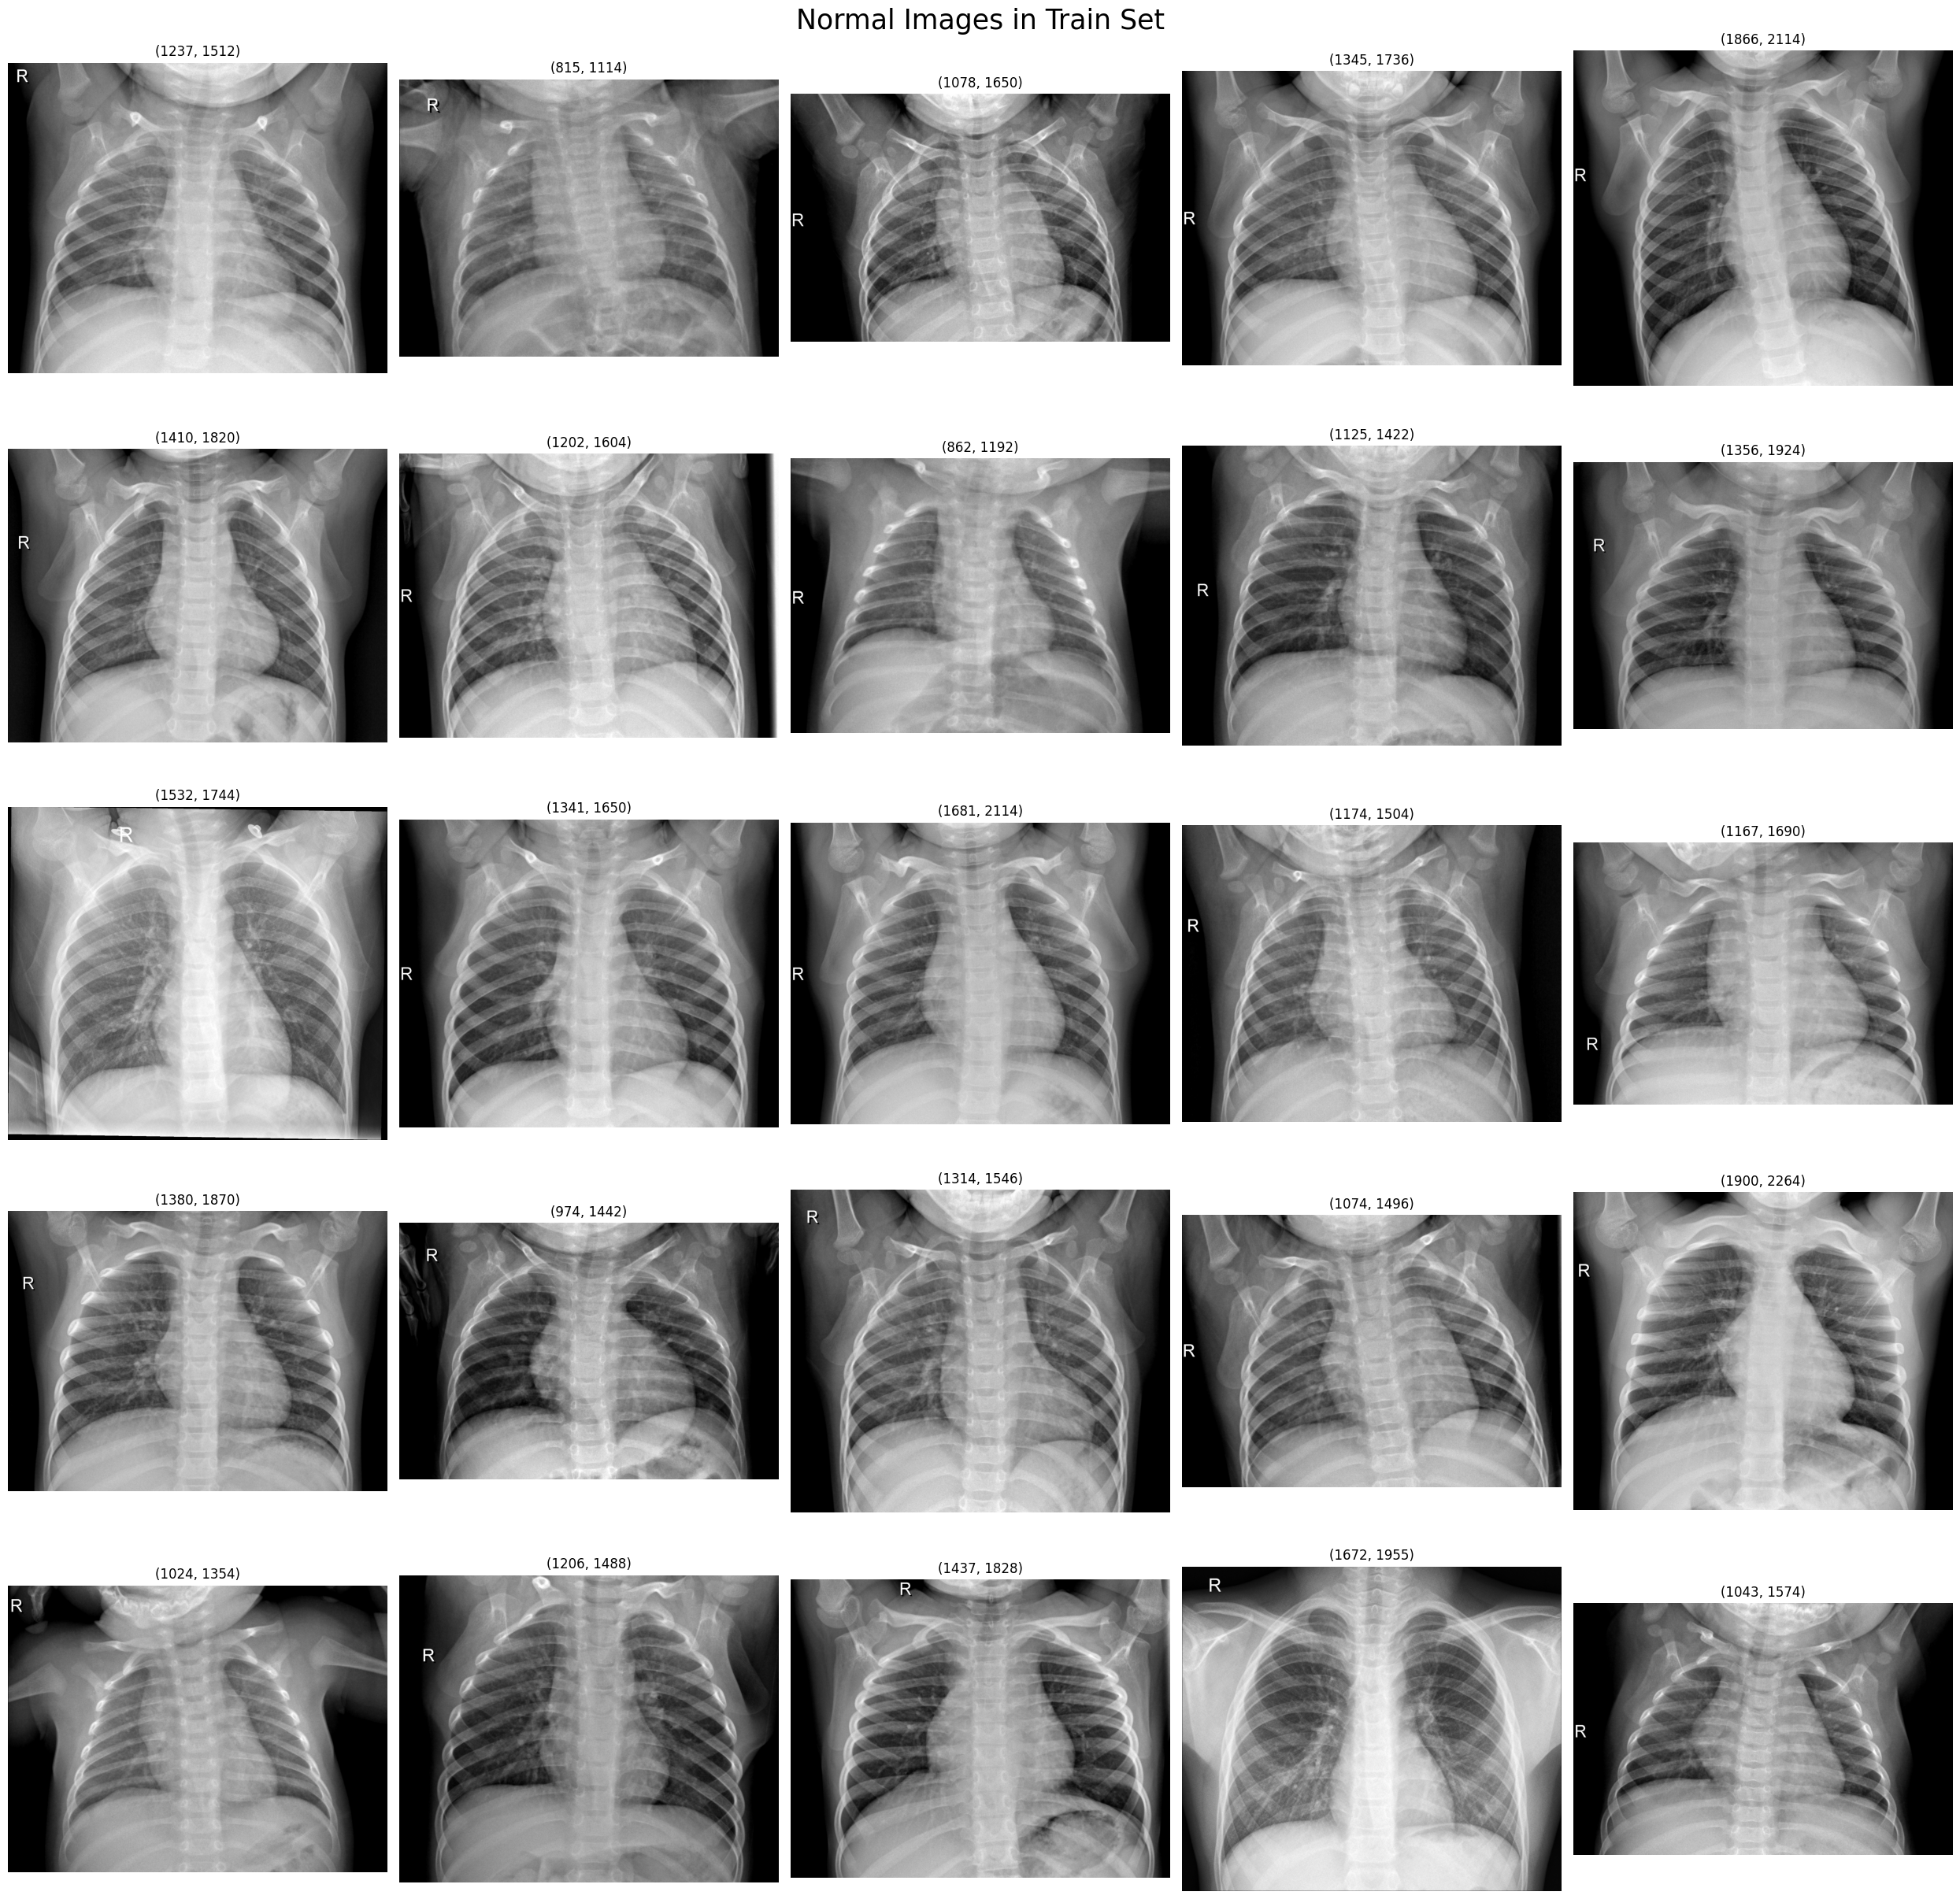

In [25]:
import cv2
IMG_ROOT = "chest_xray/chest_xray/train/NORMAL"
train_normal = os.listdir(r"/home/charis/Desktop/Projects/X-Ray ~ Pneumonia/Chest-X-Ray-Images-Pneumonia-classification-/chest_xray/chest_xray/train/NORMAL")

# Get image as numpy array
def load_image(name, path):
    img_path = plt.imread(os.path.join(IMG_ROOT, name))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    return img

# Plot numpy array
def plot_image(img):
    plt.imshow(img)
    plt.title(img.shape)
    
# Plot a grid of examples
def plot_grid(img_names, img_root = IMG_ROOT, rows=5, cols=5, title=""):
    fig = plt.figure(figsize=(25,25))
    plt.suptitle(title, fontsize=25)

    for i,name in enumerate(img_names):
        plt.subplot(rows, cols, i + 1)
        img = plt.imread(os.path.join(img_root, name))
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        plt.title(img.shape)
    plt.tight_layout()
    plt.show()

# plot the normal images in the train set (NOT pneumonia)
plot_grid(train_normal[:25], title="Normal Images in Train Set")

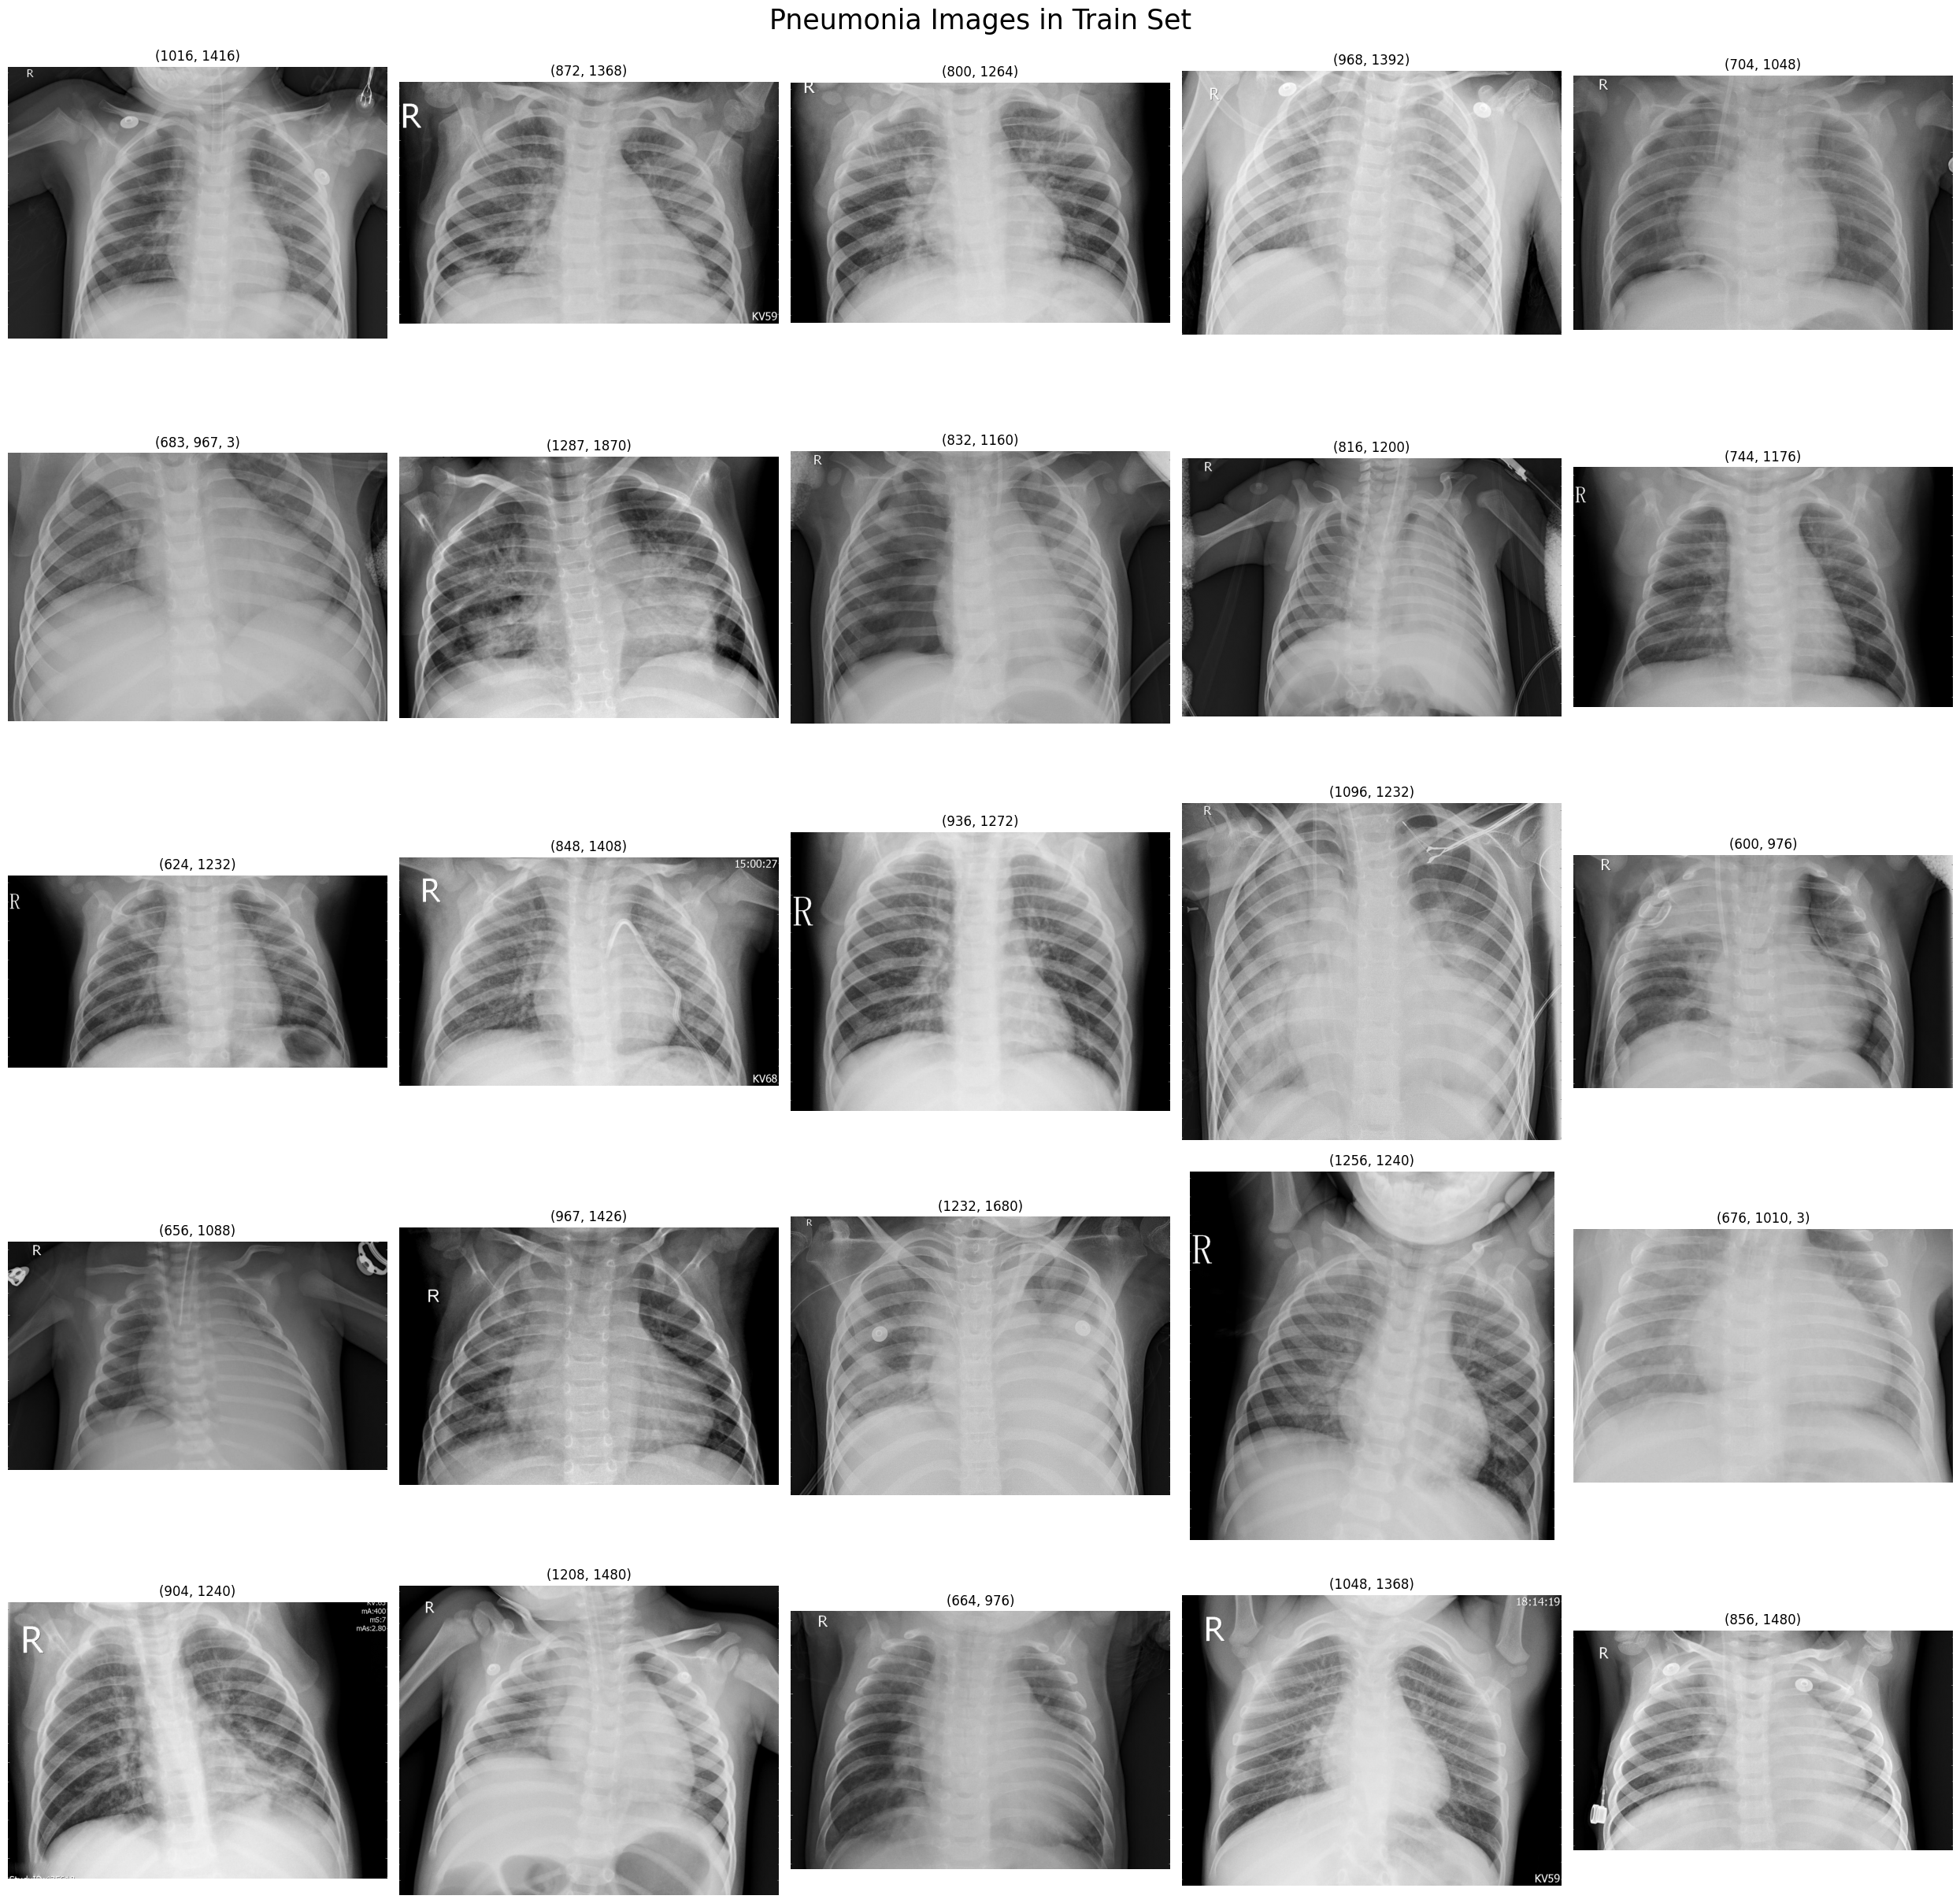

In [26]:
second_IMG_ROOT = "chest_xray/chest_xray/train/PNEUMONIA"

plot_grid(train_pneumonia[:25], img_root=second_IMG_ROOT, title="Pneumonia Images in Train Set")

# Check the distribution of pixel value.
(For a sample of images)

In [39]:
IMG_ROOT = "chest_xray/chest_xray/train/NORMAL"
def plot_grid2(img_names, img_root = IMG_ROOT, rows=5, cols=5, title=""):
    fig = plt.figure(figsize=(25,25))
    plt.suptitle(title, fontsize=25)
    for i, filename in enumerate(img_names):
        plt.subplot(rows, cols, i + 1)
        img = plt.imread(os.path.join(img_root, filename))
        sns.histplot(img.ravel(),label=f"Pixel Mean {np.mean(img):.4f} & Standard Deviation {np.std(img):.4f}", kde=False)

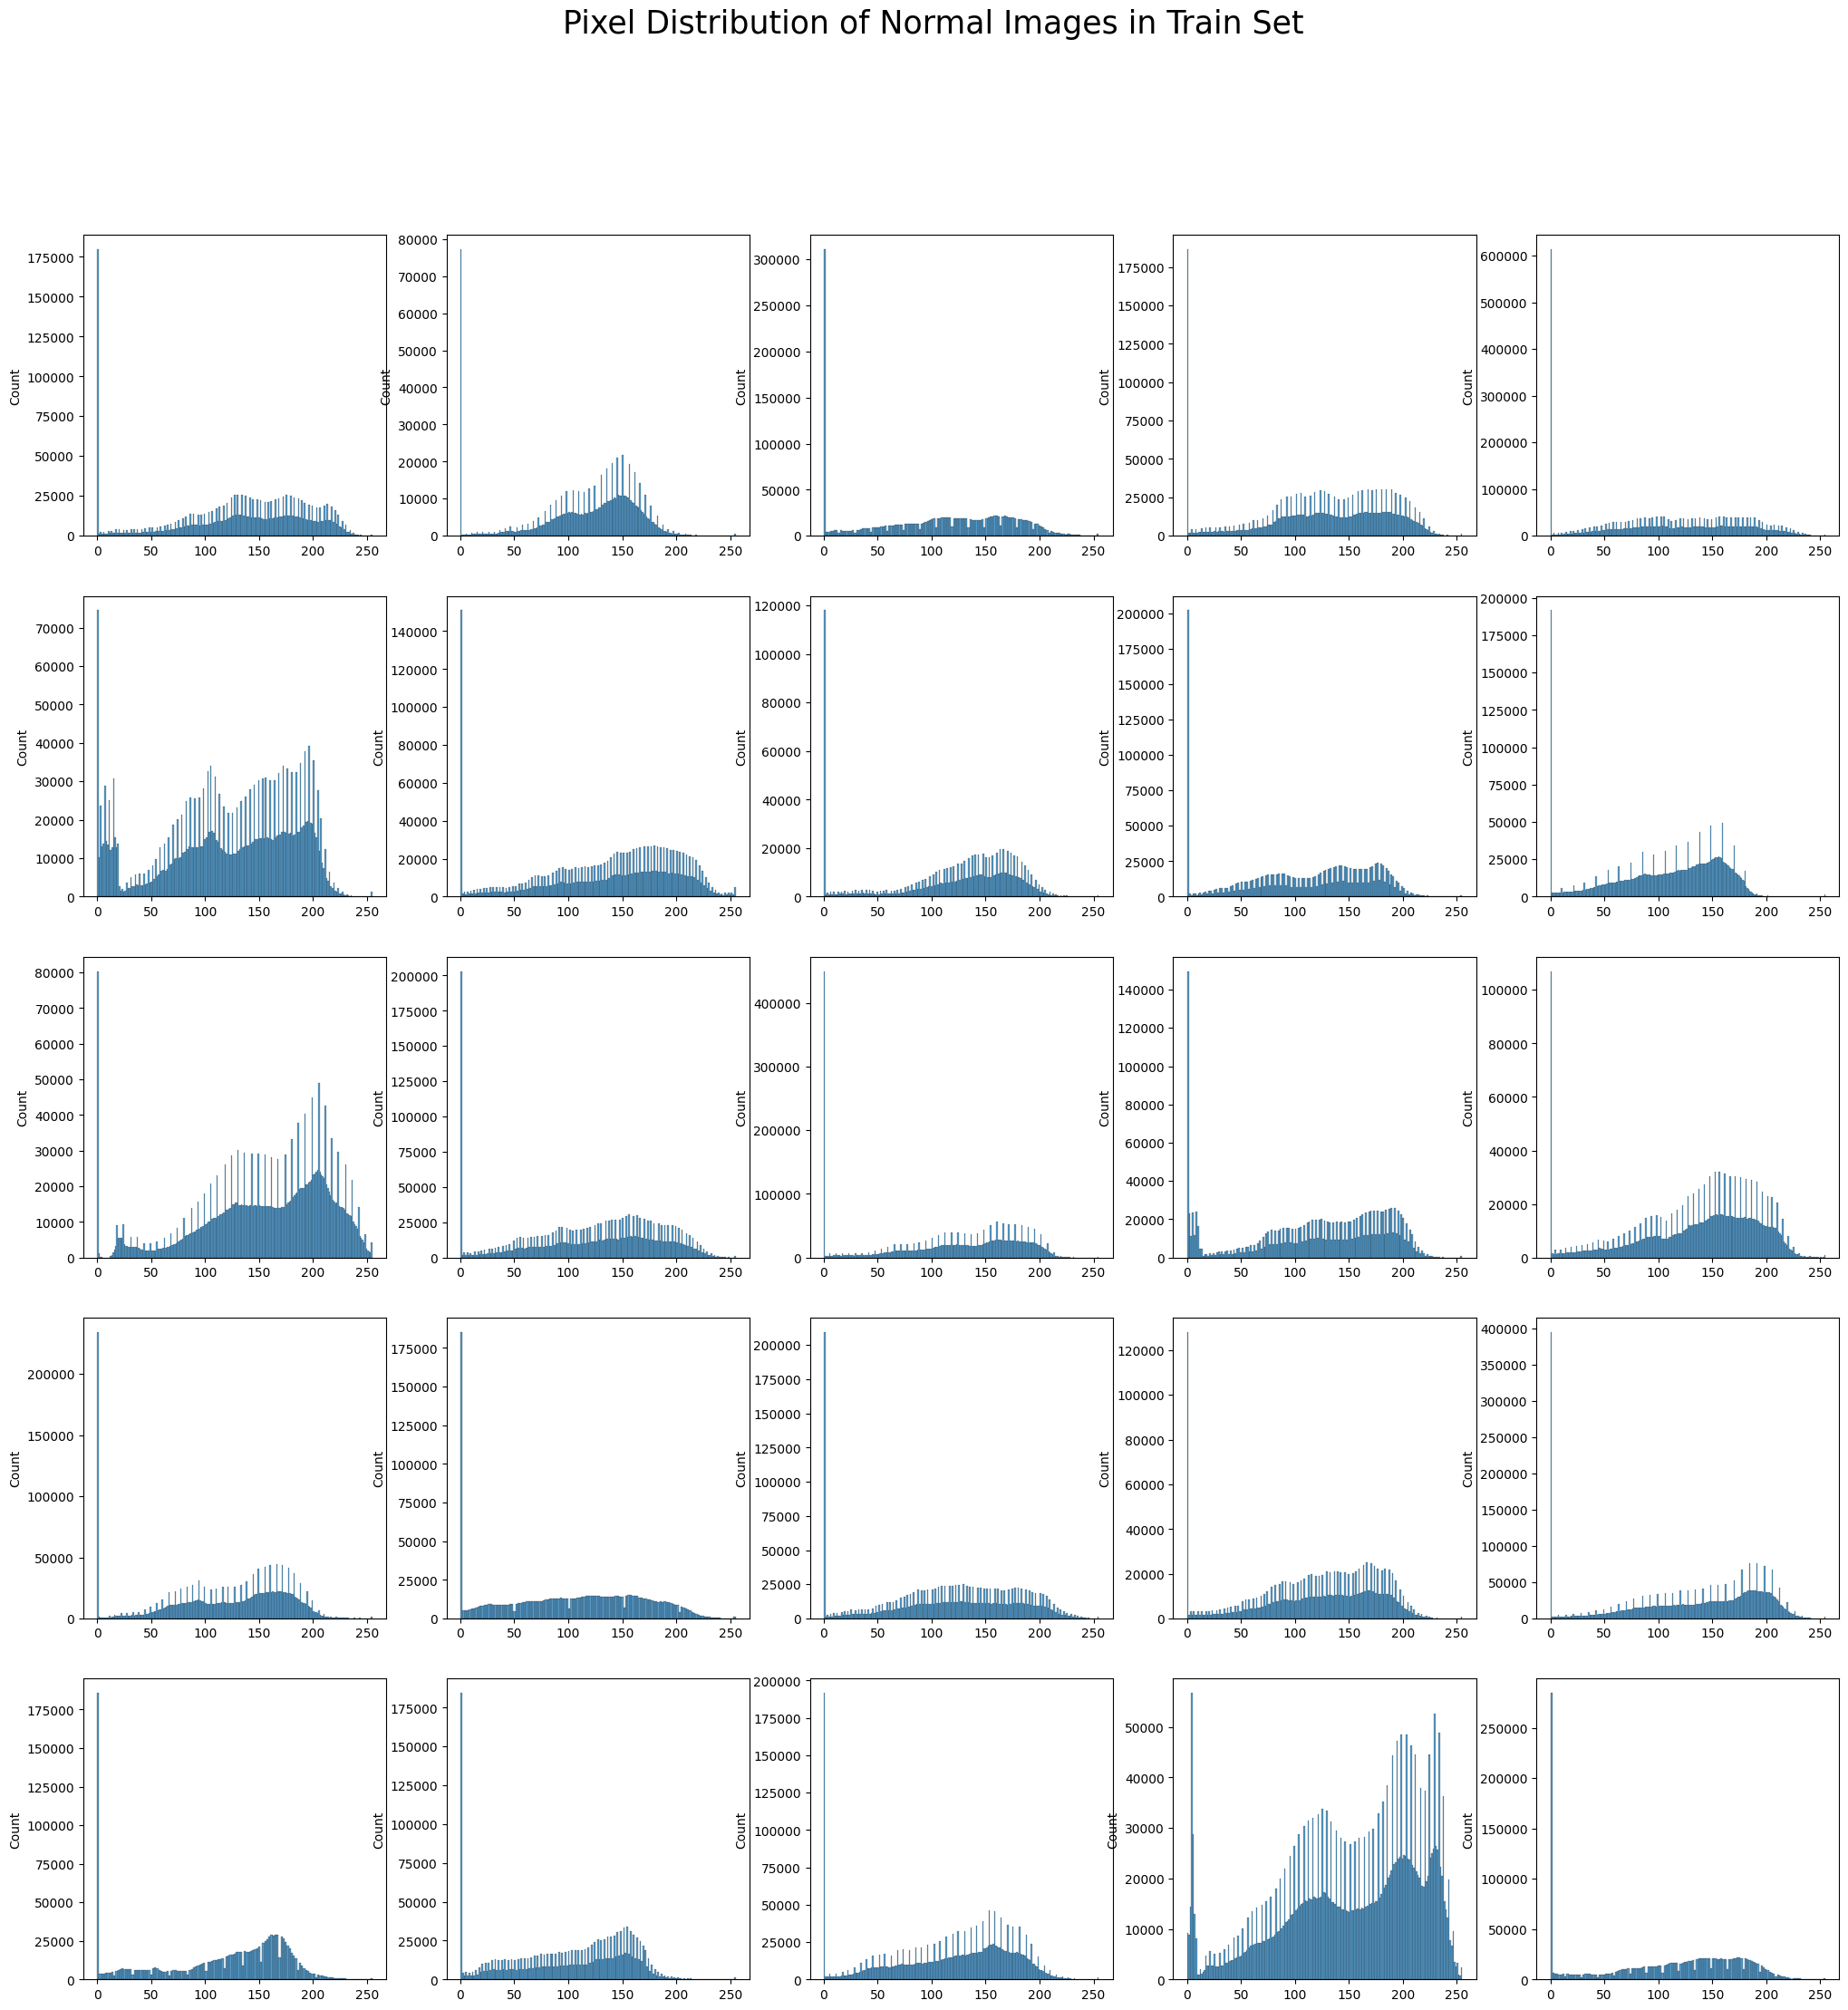

In [40]:
plot_grid2(train_normal[:25], title="Pixel Distribution of Normal Images in Train Set")

# Preprocess the training data.

In [43]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = datagen.flow_from_directory(
    '/home/charis/Desktop/Projects/X-Ray ~ Pneumonia/Chest-X-Ray-Images-Pneumonia-classification-/chest_xray/chest_xray/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)


Found 5216 images belonging to 2 classes.


Rescales the pixel values by the given factor (e.g., 1./255 normalizes [0,255] to [0,1]).<br>

rotation_range	40 Degrees range for random rotations.<br>

width_shift_range	0.2 Fraction of total width for horizontal shifts.<br>

height_shift_range 0.2 Fraction of total height for vertical shifts.<br>

shear_range 0.2	Shear angle in degrees.<br>

zoom_range 0.2 Range for random zoom operations.<br>

horizontal_flip	Boolean, whether to randomly flip images horizontally.<br>

fill_mode	Strategy for filling in newly created pixels after a transformation (e.g., 'nearest').

In [45]:
train_generator.class_indices

{'NORMAL': 0, 'PNEUMONIA': 1}

In [48]:
train_generator.image_shape  

(150, 150, 3)

In [49]:
train_generator[0]

(array([[[[0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ],
          ...,
          [0.54150593, 0.54150593, 0.54150593],
          [0.5210007 , 0.5210007 , 0.5210007 ],
          [0.4558223 , 0.4558223 , 0.4558223 ]],
 
         [[0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ],
          ...,
          [0.54921514, 0.54921514, 0.54921514],
          [0.52913016, 0.52913016, 0.52913016],
          [0.4216628 , 0.4216628 , 0.4216628 ]],
 
         [[0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ],
          ...,
          [0.50967777, 0.50967777, 0.50967777],
          [0.5212605 , 0.5212605 , 0.5212605 ],
          [0.3625545 , 0.3625545 , 0.3625545 ]],
 
         ...,
 
         [[0.77997327, 0.77997327, 0.77997327],
          [0.78258

In [51]:
from collections import Counter

Counter(train_generator.classes)

Counter({np.int32(1): 3875, np.int32(0): 1341})

So the data are still imbalanced.

In [ ]:
from sklearn.utils import class_weight, compute_class_weight

# FIx the imbalance in the dataset by computing class weights and passing them to the model during training!!!!!
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))
